<a href="https://colab.research.google.com/github/TomaszPasnikowski/ML_2026_homeworks/blob/main/LAB1_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
url = "https://raw.githubusercontent.com/SzymonNowakowski/Machine-Learning-2025L/refs/heads/master/PCA_three_clusters_data.csv"
df = pd.read_csv(url)
df.head()

,x,y,z,class
0,0.647689,-0.138264,3.512299,0
1,-0.234137,-0.234153,10.769447,0
2,-0.469474,0.767435,11.166721,0
3,-0.465730,-0.463418,3.836479,0
4,-1.724918,-1.913280,1.710932,0


In [3]:
print(df.var())

x         5.291709
y         2.339093
z        40.024955
class     0.668896
dtype: float64


When variables in dataset are measured in different scales, most often the variance will differ significantly. The PCA algorithm, aiming to maximize the variance of orthogonal vectors, will construct the components in a way that puts more weight on the high-variance features even if they add little information to the data.  

As one can see, in this dataset the variance of the variable $z$ is much higher than the variance of the other predictors. It is therefore generally good to standardize the data before performing PCA so that one variable doesn't dominate the whole analysis.

In [4]:
X = df.iloc[:, :-1].copy()
y = df["class"]

scaler= StandardScaler()
X = scaler.fit_transform(X)

pca = PCA(n_components= 2)
XV = pca.fit_transform(X)

df_pca = pd.DataFrame(data= XV, columns= ["PC1", "PC2"])
df_pca["class"] = df["class"]


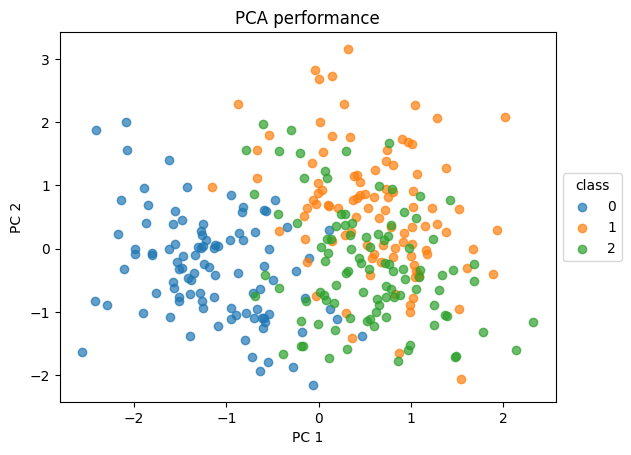

In [5]:
colormap = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax= plt.subplots()
for c, col in zip(df_pca["class"].unique(), colormap):
    ax.scatter(df_pca[df_pca["class"] == c]["PC1"], df_pca[df_pca["class"] == c]["PC2"], c= col, label= c, alpha= 0.7)
ax.legend(title= "class", loc= "center left", bbox_to_anchor= (1, 0.5))
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("PCA performance")
plt.show()

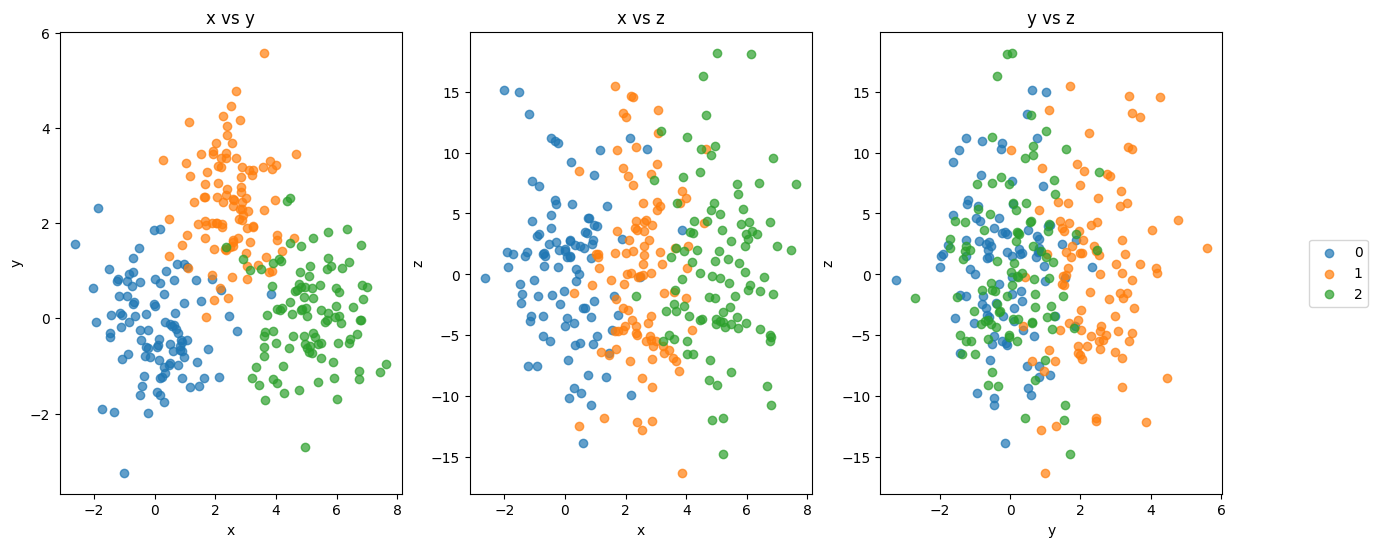

In [6]:
colormap = ["#1f77b4", "#ff7f0e", "#2ca02c"]
fig, axs = plt.subplots(1, 3)
fig.set_figheight(6)
fig.set_figwidth(15)

axs[0].set_title("x vs y")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
for c, col in zip(df["class"].unique(), colormap):
    axs[0].scatter(df[df["class"] == c]["x"], df[df["class"] == c]["y"], color= col, alpha= 0.7, label= c)

axs[1].set_title("x vs z")
axs[1].set_xlabel("x")
axs[1].set_ylabel("z")
for c, col in zip(df["class"].unique(), colormap):
    axs[1].scatter(df[df["class"] == c]["x"], df[df["class"] == c]["z"], color= col, alpha= 0.7, label= c)

axs[2].set_title("y vs z")
axs[2].set_xlabel("y")
axs[2].set_ylabel("z")
for c, col in zip(df["class"].unique(), colormap):
    axs[2].scatter(df[df["class"] == c]["y"], df[df["class"] == c]["z"], color= col, alpha= 0.7, label= c)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc= "right")
plt.show()

In [7]:
df = df.copy()

df["class_0"] = df["class"] == 0
df["class_1"] = df["class"] == 1
df["class_2"] = df["class"] == 2

df.corr()

,x,y,z,class,class_0,class_1,class_2
x,1.000000,0.034832,-0.025644,8.929388e-01,-0.765770,-1.507466e-02,0.780845
y,0.034832,1.000000,0.003411,6.841713e-02,-0.436645,7.547890e-01,-0.318144
z,-0.025644,0.003411,1.000000,-7.191941e-03,0.019614,-2.677185e-02,0.007158
class,0.892939,0.068417,-0.007192,1.000000e+00,-0.866025,1.509526e-16,0.866025
class_0,-0.765770,-0.436645,0.019614,-8.660254e-01,1.000000,-5.000000e-01,-0.500000
class_1,-0.015075,0.754789,-0.026772,1.509526e-16,-0.500000,1.000000e+00,-0.500000
class_2,0.780845,-0.318144,0.007158,8.660254e-01,-0.500000,-5.000000e-01,1.000000


The scatterplots with regard to the PCA components show some regularitiy among the $class$ distribution but it fails to make any distinguishment between classes $1$ and $2$ which makes the PCA analysis seem counterproductive with plot $x$ vs $y$ showing clear divisions between classes (and plot $x$ vs $z$ also being quite informative). This is explainable by the fact that the PCA algorithm maximizes variance of the predictor variables, complitely ignoring their relation to the target. <br><br>

A simple analysis shows that the variable $x$ alone explains majority of the $class$ distribution $(correlation = 0.89)$. Because the Pearson correlation factor measures linear dependence and the class variable is cathegorical, for the purpose of further analysis, it has been one-hot encoded. This approach lets us notice that $y$ is positively correlated to the $class$ being 1 and nagatively correlated to it being $0$ or $2$. The $z$ variable seems to be completely uncorrelated with the target variable. It is also worth noting that all three predictors are pair-wise uncorrelated with each other (i.e. they are already orthogonal before PCA).<br><br>

Graphical analysis of the distributions (described below) confirms those observations - the information about belonging to any class is contained almost entirely in variables $x$ and $y$. The variable $z$ only adds noise to the analysis and therefore negatively impacts the performance of principal components.

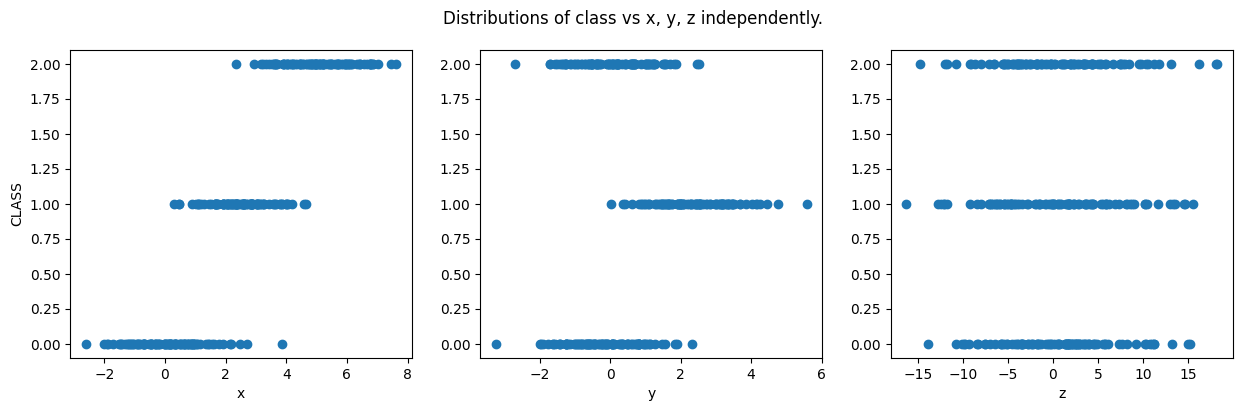

In [8]:
fig, axs = plt.subplots(1, 3, figsize= (15, 4))
axs[0].scatter(x = df["x"], y= df["class"])
axs[0].set_xlabel("x")
axs[0].set_ylabel("CLASS")
axs[1].scatter(x = df["y"], y= df["class"])
axs[1].set_xlabel("y")
axs[2].scatter(x = df["z"], y= df["class"])
axs[2].set_xlabel("z")
fig.suptitle("Distributions of class vs x, y, z independently.")
plt.show()

Conditional distributions $p(z | class = 1)$, $p(z | class = 2)$, $p(z | class = 2)$ look very simmilar, whereas for $p(x|class)$ and $p(y|class)$ significant shifts can be observed.

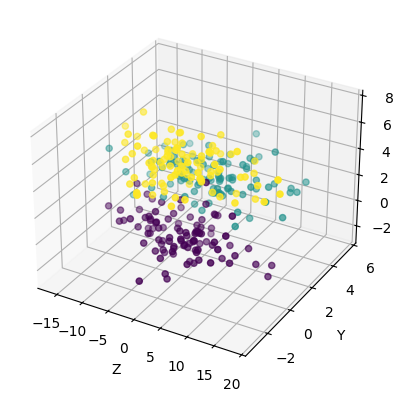

In [9]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(df.z, df.y, df.x, c= df["class"])
ax.set_xlabel('Z')
ax.set_ylabel('Y')
ax.set_zlabel('X')
plt.show()

The 3-d plot indicates that the observations form 3 distinctive clouds distributed mainly over the $x$ and $y$ axis. The $z$ variable doesn't add much information regarding to the class.
Plots from other perspectives are shown below.

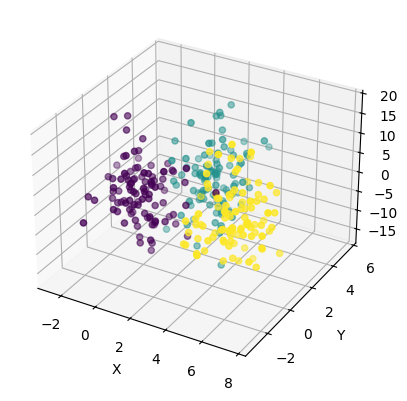

In [10]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(df.x, df.y, df.z, c= df["class"])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

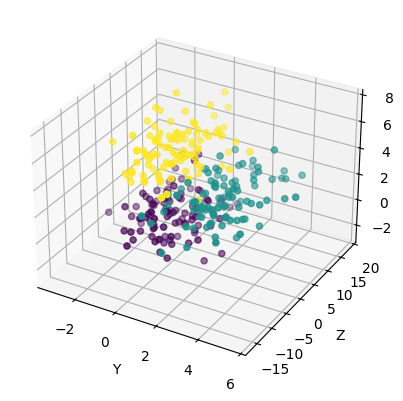

In [11]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(df.y, df.z, df.x, c= df["class"])
ax.set_xlabel('Y')
ax.set_ylabel('Z')
ax.set_zlabel('X')
plt.show()